In [1]:
#Import models and libraries
from DT.DecisionTree import DecisionTree
from sklearn.tree import DecisionTreeClassifier
from GNB.gaussian_naive_bayes import GNB
from LogisticRegresssion.LogisticRegression import LogReg
from tensorflow import keras
from SVM.linear_svm import LinearSVMScartch
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , f1_score
from sklearn.model_selection import train_test_split
from Kfolds import run_kfold
from KNN import CustomKNN, find_optimal_k, make_knn_trainer, predict_knn




c:\Users\Moaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Moaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Moaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/

In [2]:
#Download Data
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()


In [3]:
y_train_bin = (y_train == 6).astype(int)
y_test_bin  = (y_test == 6).astype(int)
# y_train_bin = np.where(y_train == 6, 1, -1)
# y_test_bin  = np.where(y_test == 6, 1, -1)

# Flatten
# X_train = X_train.reshape(X_train.shape[0], -1)
# X_test = X_test.reshape(X_test.shape[0], -1)


In [4]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0
X_train_f = X_train.reshape(X_train.shape[0], -1)
X_test_f = X_test.reshape(X_test.shape[0], -1)

In [5]:
import numpy as np
from skimage.feature import hog

def extract_hog_features(X):
    features = []

    for img in X:
        img_2d = img.reshape(28, 28)

        hog_features = hog(
            img_2d,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            feature_vector=True
        )

        features.append(hog_features)

    return np.array(features)

In [6]:
#HOG ONLY
X_train_HOG = extract_hog_features(X_train)
X_test_HOG = extract_hog_features(X_test)

In [7]:
#HOG + PCA
pca = PCA(n_components=50)  

X_train_hog_pca = pca.fit_transform(X_train_HOG)
X_test_hog_pca = pca.transform(X_test_HOG)

In [8]:
#PCA only
pca2 = PCA(n_components=50)  
X_train_pca = pca2.fit_transform(X_train_f)
X_test_pca = pca2.transform(X_test_f)

In [9]:
print(X_test_hog_pca.shape)

(10000, 50)


In [ ]:
#Decision Tree results
# def train_DT(X, y):
#     dt = DecisionTree(maxDepth = 12,
#     minSamplesSplit = 10,
#     minSampleLeafs = 5,
#     criterion = "entropy",
#     maxFeatures = "sqrt",
#     classWeights = {0: 1, 1: 1}
#     )
#     dt.fit(X, y)
#     return dt
# def predict_DT(model, X):
#     return model.predict(X)

#Validation
print("Validation results")
# run_kfold(X_train_HOG , y_train_bin , train_DT , predict_DT)

dt = DecisionTree(maxDepth = 12,
    minSamplesSplit = 10,
    minSampleLeafs = 5,
    criterion = "gini",
    classWeights = {0: 1, 1: 1},
    maxFeatures='sqrt',
    randomState=42
    )


dt.fit(X_train_HOG ,y_train_bin )
predictions = dt.predict(X_test_HOG)
print(classification_report(
    y_test_bin, predictions,
    target_names=["Not 6", "Is 6"]
))



Validation results
              precision    recall  f1-score   support

       Not 6       0.99      0.99      0.99      9042
        Is 6       0.94      0.87      0.91       958

    accuracy                           0.98     10000
   macro avg       0.96      0.93      0.95     10000
weighted avg       0.98      0.98      0.98     10000



In [ ]:
import numpy as np
from sklearn.metrics import classification_report


print("Starting Comprehensive Evaluation: Preprocessing vs. Weights...\n")


base_lr_params = {
    'max_iterations': 1000,
    'learning_rate': 0.01,
}

datasets = {
    "Raw Pixels": (X_train_f, X_test_f),
    "PCA Only": (X_train_pca, X_test_pca),
    "HOG Only": (X_train_HOG, X_test_HOG),
    "HOG + PCA": (X_train_hog_pca, X_test_hog_pca)
}


weight_configs = {
    "No Weights": None,
    "Balanced": "balanced",
    "Custom (1:5)": {0: 1, 1: 5} 
}


results_matrix = {data_name: {} for data_name in datasets.keys()}

for data_name, (X_tr, X_te) in datasets.items():
    print(f"\n{'='*70}")
    print(f"EVALUATING DATASET: {data_name}")
    print(f"{'='*70}")
    
    for weight_name, weight_val in weight_configs.items():
        print(f"\n--- Weight Config: {weight_name} ---")
        
        
        def train_lr(X_train_fold, y_train_fold):
            model = LogReg(**base_lr_params, class_weight=weight_val)
            model.fit(X_train_fold, y_train_fold)
            return model

        def predict_lr(model, X_val_fold):
            return model.predict(X_val_fold)
        
        
        avg_kfold_f1, _ = run_kfold(X_tr, y_train_bin, train_lr, predict_lr, k=5, binary=1)
        results_matrix[data_name][weight_name] = avg_kfold_f1
        
        print(f"K-Fold Validation F1 : {avg_kfold_f1:.4f}")
        
       
        final_model = LogReg(**base_lr_params, class_weight=weight_val)
        final_model.fit(X_tr, y_train_bin)
        
        
        test_preds = final_model.predict(X_te)
        
        
        print("Test Set Classification Report:")
        print(classification_report(y_test_bin, test_preds, target_names=["Not 6", "Is 6"], digits=4))


print("\n" + "="*70)
print("SUMMARY MATRIX: Preprocessing vs. Weights (K-Fold F1)")
print("="*70)
print(f"{'Preprocessing':<15} | {'No Weights':<15} | {'Balanced':<15} | {'Custom (1:5)':<15}")
print("-" * 70)

for data_name, weight_results in results_matrix.items():
    no_wt = weight_results["No Weights"]
    bal_wt = weight_results["Balanced"]
    cust_wt = weight_results["Custom (1:5)"]
    print(f"{data_name:<15} | {no_wt:<15.4f} | {bal_wt:<15.4f} | {cust_wt:<15.4f}")

Starting Comprehensive Evaluation: Preprocessing vs. Weights...


EVALUATING DATASET: Raw Pixels

--- Weight Config: No Weights ---
Fold 1 → F1: 0.8680
Fold 2 → F1: 0.8590
Fold 3 → F1: 0.8544
Fold 4 → F1: 0.8492
Fold 5 → F1: 0.8530

K-Fold Avg F1: 0.8566963276913657
K-Fold Validation F1 : 0.8567
Test Set Classification Report:
              precision    recall  f1-score   support

       Not 6     0.9767    0.9950    0.9858      9042
        Is 6     0.9429    0.7756    0.8511       958

    accuracy                         0.9740     10000
   macro avg     0.9598    0.8853    0.9184     10000
weighted avg     0.9734    0.9740    0.9729     10000


--- Weight Config: Balanced ---
Fold 1 → F1: 0.8310
Fold 2 → F1: 0.8321
Fold 3 → F1: 0.8165
Fold 4 → F1: 0.8179
Fold 5 → F1: 0.8307

K-Fold Avg F1: 0.8256429191168861
K-Fold Validation F1 : 0.8256
Test Set Classification Report:
              precision    recall  f1-score   support

       Not 6     0.9963    0.9579    0.9767      9042
     

In [ ]:
import pickle
from LogisticRegresssion.LogisticRegression import LogReg 

print("Training final production model...")


production_model = LogReg(
    max_iterations=1000, 
    learning_rate=0.01, 
    class_weight={0: 1, 1: 5},
    reg_eqn=None,
    reg_param=0
)


production_model.fit(X_train_HOG, y_train_bin)


filename = 'custom_logreg_hog.pkl'
with open(filename, 'wb') as file:
    pickle.dump(production_model, file)

print(f"Success! Model saved as {filename}")

Training final production model...
Success! Model saved as custom_logreg_hog.pkl


In [10]:
from sklearn.metrics import confusion_matrix
import pandas as pd
final_model = LogReg(
    max_iterations=1000, 
    learning_rate=0.01,
    class_weight={0: 1, 1: 5},
    reg_eqn=None, 
    reg_param=0
)

print("Training the final model...")
final_model.fit(X_train_HOG, y_train_bin)

print("Predicting...")
test_preds = final_model.predict(X_test_HOG)

cm = confusion_matrix(y_test_bin, test_preds)

cm_df = pd.DataFrame(
    cm, 
    index=['Actual: Not 6 (0)', 'Actual: Is 6 (1)'], 
    columns=['Predicted: Not 6 (0)', 'Predicted: Is 6 (1)']
)

print("\nFinal Confusion Matrix:\n")
print(cm_df)

Training the final model...
Predicting...

Final Confusion Matrix:

                   Predicted: Not 6 (0)  Predicted: Is 6 (1)
Actual: Not 6 (0)                  8986                   56
Actual: Is 6 (1)                     33                  925


Final Confusion Matrix:

                   Predicted: Is 6 (1)  Predicted: Not 6 (0)
Actual: Is 6 (1)                   925                    33
Actual: Not 6 (0)                   56                  8986

Generating heatmap image...


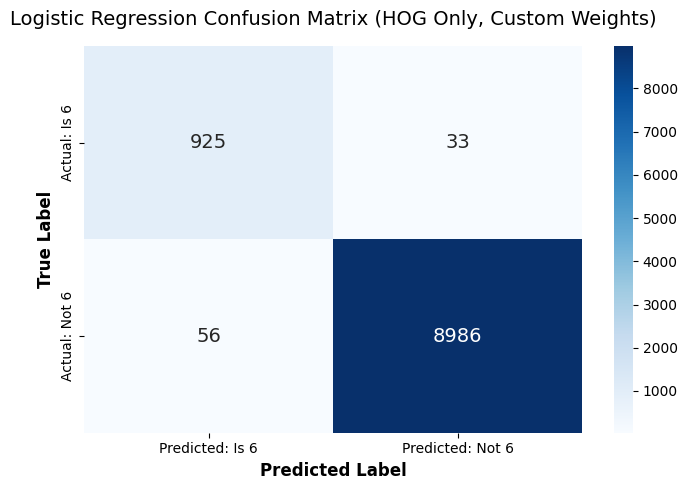

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# 1. Generate the raw confusion matrix, explicitly setting '1' (Is 6) to come first
cm = confusion_matrix(y_test_bin, test_preds, labels=[1, 0])

# 2. Format it nicely into a pandas DataFrame for printing
cm_df = pd.DataFrame(
    cm, 
    index=['Actual: Is 6 (1)', 'Actual: Not 6 (0)'], 
    columns=['Predicted: Is 6 (1)', 'Predicted: Not 6 (0)']
)

print("Final Confusion Matrix:\n")
print(cm_df)
print("\nGenerating heatmap image...")

# 3. Set up the figure size for the heatmap
plt.figure(figsize=(7, 5))

# 4. Draw the heatmap (Labels are updated to match the [1, 0] order)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: Is 6', 'Predicted: Not 6'],
            yticklabels=['Actual: Is 6', 'Actual: Not 6'],
            annot_kws={"size": 14}) 

# 5. Add titles and labels
plt.title('Logistic Regression Confusion Matrix (HOG Only, Custom Weights)', fontsize=14, pad=15)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')

# Ensure nothing gets cut off
plt.tight_layout()

# 6. Save it as a high-resolution image!
plt.savefig('logistic_regression_cm_positive_first.png', dpi=300)

# Display it in your notebook
plt.show()

In [ ]:
Validation split from training data
X_train, X_val, y_train, y_val = train_test_split(
    X_train_hog_pca, y_train_bin,
    test_size=0.2,
    stratify=y_train_bin,
    random_state=42
)

# Train
gnb = GNB()
gnb.gaussian_naive_train(X_train, y_train)

# Tune weights
best_weight = None
best_score = -1

for w in [1, 1.5, 2, 3, 4, 5, 7, 10]:
    class_weights = {0: 1.0, 1: w}
    preds = gnb.predict(X_val, class_weights=class_weights)
    score = f1_score(y_val, preds, pos_label=1)

    print(f"Weight {w} → F1: {score:.4f}")

    if score > best_score:
        best_score = score
        best_weight = w

print("\n🔥 Best weight:", best_weight)

def train_gnb(X, y):
    gnb = GNB()
    gnb.gaussian_naive_train(X, y)
    return gnb


def predict_gnb(model, X):
    return model.predict(
        X,
        class_weights={0: 1.0, 1: best_weight}
    )


# ======================
# STEP 2: K-FOLD
# ======================
print("\n=== K-FOLD VALIDATION ===")
run_kfold(X_train, y_train, train_gnb, predict_gnb, k=5)


# ======================
# STEP 3: FINAL TEST
# ======================
print("\n=== FINAL TEST RESULTS ===")

gnb = GNB()
gnb.gaussian_naive_train(X_train, y_train)

predictions = gnb.predict(
    X_test_hog_pca,   # ✅ CORRECT
    class_weights={0: 1.0, 1: best_weight}
)

print(classification_report(
    y_test_bin,
    predictions,
    target_names=["Not 6", "Is 6"]
))

In [ ]:
#N7ot adham fi pickle
import pickle


model_package = {
    "model": gnb,
    "pca": pca,
    "best_weight": best_weight,
    "hog_params": {
        "orientations": 9,
        "pixels_per_cell": (4, 4),
        "cells_per_block": (2, 2),
        "block_norm": "L2-Hys"
    }
}

# 3. Save to file
with open("pickleGNB/gnb_digit6_package.pkl", "wb") as f:
    pickle.dump(model_package, f)

In [ ]:
lg = LogReg(max_iterations=1000 , learning_rate=0.1 , threshold=0.5)
print("Validation results")
run_kfold(X_val , y_val , lg.fit , lg.predict)

lg.fit(X_train , y_train)
predictions = lg.predict(X_test_hog_pca)
print(classification_report(
    y_test_bin,
    predictions,
    target_names=["Not 6", "Is 6"]
))

In [15]:
svm = LinearSVMScartch(
    C=1.0,
    learning_rate=0.0001,
    n_epochs=100,
    batch_size=128,
    use_class_weights=True,
    random_state=42
)
# print("Validation results")
# run_kfold(X_val , y_val , svm.fit , svm.predict)

svm.fit(X_train , y_train)
predictions = svm.predict(X_test_hog_pca)
print(classification_report(
    y_test_bin,
    predictions,
    target_names=["Not 6", "Is 6"]
))

ValueError: too many values to unpack (expected 2)

In [ ]:
print("=== KNN: Finding Optimal K ===")
best_k = find_optimal_k(X_train, y_train, X_val, y_val, max_k=15, weights="distance")

subset_size = min(10000, len(X_train))
subset_idx = np.random.RandomState(42).choice(len(X_train), subset_size, replace=False)
X_sub, y_sub = X_train[subset_idx], y_train[subset_idx]

print(f"=== KNN K-Fold (k={best_k}, 5-fold on {subset_size} subset) ===")
train_knn = make_knn_trainer(best_k, weights="distance")
run_kfold(X_sub, y_sub, train_knn, predict_knn, k=5)

print(f"=== Final KNN (k={best_k}, distance weighting) ===")
knn_final = CustomKNN(k=best_k, weights="distance")
knn_final.fit(X_train, y_train)

knn_preds = knn_final.predict(X_test_hog_pca)
y_test_knn = (y_test == 6).astype(int)

print(classification_report(
    y_test_knn,
    knn_preds,
    target_names=["Not 6", "Is 6"]
))


=== KNN: Finding Optimal K ===
K Value    | Validation Error     | Accuracy  
---------------------------------------------
1          | 0.0032               | 0.9968    
3          | 0.0033               | 0.9967    
5          | 0.0030               | 0.9970    
7          | 0.0029               | 0.9971    
9          | 0.0029               | 0.9971    
11         | 0.0035               | 0.9965    
13         | 0.0034               | 0.9966    
15         | 0.0034               | 0.9966    
---------------------------------------------
Optimal K found at K = 7 with Error = 0.0029
=== KNN K-Fold (k=7, 5-fold on 10000 subset) ===
Fold 1 → F1: 0.9846
Fold 2 → F1: 0.9718
Fold 3 → F1: 0.9825
Fold 4 → F1: 0.9645
Fold 5 → F1: 0.9766

K-Fold Avg F1: 0.976012978919466
=== Final KNN (k=7, distance weighting) ===
              precision    recall  f1-score   support

       Not 6       1.00      1.00      1.00      9042
        Is 6       0.98      0.99      0.98       958

    accuracy      